In [2]:
library(ggplot2)
library(tidyverse)
library(dplyr)
library(vegan)
library(cowplot)
library(see)
library(ggeffects)

── Attaching core tidyverse packages ───────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1
── Conflicts ─────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute──────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp



Attaching package: ‘ggeffects’


The following object is maske

# File reading=========================================================================================================================================

In [3]:
tp1_shannon_combined <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/feacal/tp1_nulliparous/tp1_alpha_beta_diversity/alpha/2025-09-19_tp1_shannon.csv", header = TRUE)
dim(tp1_shannon_combined)
head(tp1_shannon_combined)

[1] 50  4

,Sample_ID,Shannon,Group,Personal_number
,<dbl>,<dbl>,<chr>,<chr>
1,100000115046,4.517399,Nulliparous,P159f9c8
2,100000133514,4.461396,Nulliparous,P1a267fa
3,100000141564,4.007270,Nulliparous,P1ef420d
4,100000112861,3.939268,Nulliparous,P1f862a6
5,100000116982,4.340309,Nulliparous,P3c0f6ee
6,100000117590,4.061135,Nulliparous,P3cac7b0


In [4]:
tp2_shannon_combined <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/feacal/tp2_nulliparous/tp2_alpha_beta_diversity/alpha/2025-09-19_tp2_shannon.csv", header = TRUE)
dim(tp2_shannon_combined)
head(tp2_shannon_combined)

[1] 42  4

,Sample_ID,Shannon,Group,Personal_number
,<dbl>,<dbl>,<chr>,<chr>
1,100000112243,4.236528,Nulliparous,P159f9c8
2,100000133958,4.277826,Nulliparous,P1a267fa
3,100000168325,3.803011,Nulliparous,P1f862a6
4,100000129494,3.971679,Nulliparous,P3cac7b0
5,100000126820,4.075306,Nulliparous,P3db7da6
6,100000123362,4.105779,Nulliparous,P424fd61


In [5]:
tp1_richness_combined <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/feacal/tp1_nulliparous/tp1_alpha_beta_diversity/alpha/2025-09-19_tp1_richness.csv", header = TRUE)
dim(tp1_richness_combined)
head(tp1_richness_combined)

[1] 50  4

,Sample_ID,Species_richness,Group,Personal_number
,<dbl>,<int>,<chr>,<chr>
1,100000115046,406,Nulliparous,P159f9c8
2,100000133514,416,Nulliparous,P1a267fa
3,100000141564,304,Nulliparous,P1ef420d
4,100000112861,336,Nulliparous,P1f862a6
5,100000116982,385,Nulliparous,P3c0f6ee
6,100000117590,380,Nulliparous,P3cac7b0


In [6]:
tp2_richness_combined <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/feacal/tp2_nulliparous/tp2_alpha_beta_diversity/alpha/2025-09-19_tp2_richness.csv", header = TRUE)
dim(tp2_richness_combined)
head(tp2_richness_combined)

[1] 42  4

,Sample_ID,Species_richness,Group,Personal_number
,<dbl>,<int>,<chr>,<chr>
1,100000112243,299,Nulliparous,P159f9c8
2,100000133958,307,Nulliparous,P1a267fa
3,100000168325,311,Nulliparous,P1f862a6
4,100000129494,227,Nulliparous,P3cac7b0
5,100000126820,341,Nulliparous,P3db7da6
6,100000123362,274,Nulliparous,P424fd61


In [7]:
tp1_evenness_combined <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/feacal/tp1_nulliparous/tp1_alpha_beta_diversity/alpha/2025-09-19_tp1_evenness.csv", header = TRUE)
dim(tp1_evenness_combined)
head(tp1_evenness_combined)

[1] 50  4

,Sample_ID,Evenness,Group,Personal_number
,<dbl>,<dbl>,<chr>,<chr>
1,100000115046,0.7521035,Nulliparous,P159f9c8
2,100000133514,0.7397825,Nulliparous,P1a267fa
3,100000141564,0.7009359,Nulliparous,P1ef420d
4,100000112861,0.6771863,Nulliparous,P1f862a6
5,100000116982,0.7290663,Nulliparous,P3c0f6ee
6,100000117590,0.6836731,Nulliparous,P3cac7b0


In [8]:
tp2_evenness_combined <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/feacal/tp2_nulliparous/tp2_alpha_beta_diversity/alpha/2025-09-19_tp2_evenness.csv", header = TRUE)
dim(tp2_evenness_combined)
head(tp2_evenness_combined)

[1] 42  4

,Sample_ID,Evenness,Group,Personal_number
,<dbl>,<dbl>,<chr>,<chr>
1,100000112243,0.7431927,Nulliparous,P159f9c8
2,100000133958,0.7469774,Nulliparous,P1a267fa
3,100000168325,0.6625695,Nulliparous,P1f862a6
4,100000129494,0.7321135,Nulliparous,P3cac7b0
5,100000126820,0.6987976,Nulliparous,P3db7da6
6,100000123362,0.7314601,Nulliparous,P424fd61


In [9]:
# Simpson
tp1_simpson_combined <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/feacal/tp1_nulliparous/tp1_alpha_beta_diversity/alpha/2025-10-01_tp1_simpson.csv", header = TRUE)
dim(tp1_simpson_combined)
head(tp1_simpson_combined)

[1] 50  4

,Sample_ID,Simpson,Group,Personal_number
,<dbl>,<dbl>,<chr>,<chr>
1,100000115046,0.9728134,Nulliparous,P159f9c8
2,100000133514,0.9776683,Nulliparous,P1a267fa
3,100000141564,0.9603047,Nulliparous,P1ef420d
4,100000112861,0.9623793,Nulliparous,P1f862a6
5,100000116982,0.9773755,Nulliparous,P3c0f6ee
6,100000117590,0.9598332,Nulliparous,P3cac7b0


In [10]:
# Simpson
tp2_simpson_combined <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/feacal/tp2_nulliparous/tp2_alpha_beta_diversity/alpha/2025-10-01_tp2_simpson.csv", header = TRUE)
dim(tp2_simpson_combined)
head(tp2_simpson_combined)

[1] 42  4

,Sample_ID,Simpson,Group,Personal_number
,<dbl>,<dbl>,<chr>,<chr>
1,100000112243,0.9744463,Nulliparous,P159f9c8
2,100000133958,0.9749388,Nulliparous,P1a267fa
3,100000168325,0.9506192,Nulliparous,P1f862a6
4,100000129494,0.9701793,Nulliparous,P3cac7b0
5,100000126820,0.9640417,Nulliparous,P3db7da6
6,100000123362,0.9676004,Nulliparous,P424fd61


# $\Delta\alpha$ diversity=================================================================================================================================

## Shannon--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### First pregnancy

In [11]:
tp1_shannon_combined$Group <- as.factor(tp1_shannon_combined$Group)
head(tp1_shannon_combined)

,Sample_ID,Shannon,Group,Personal_number
,<dbl>,<dbl>,<fct>,<chr>
1,100000115046,4.517399,Nulliparous,P159f9c8
2,100000133514,4.461396,Nulliparous,P1a267fa
3,100000141564,4.007270,Nulliparous,P1ef420d
4,100000112861,3.939268,Nulliparous,P1f862a6
5,100000116982,4.340309,Nulliparous,P3c0f6ee
6,100000117590,4.061135,Nulliparous,P3cac7b0


In [12]:
# Create a df for Fp  tp1
# Need to pick rows only where Group == Nulliparous
df_fp_tp1_shan <- tp1_shannon_combined |> filter(Group == "Nulliparous")
head(df_fp_tp1_shan)

,Sample_ID,Shannon,Group,Personal_number
,<dbl>,<dbl>,<fct>,<chr>
1,100000115046,4.517399,Nulliparous,P159f9c8
2,100000133514,4.461396,Nulliparous,P1a267fa
3,100000141564,4.007270,Nulliparous,P1ef420d
4,100000112861,3.939268,Nulliparous,P1f862a6
5,100000116982,4.340309,Nulliparous,P3c0f6ee
6,100000117590,4.061135,Nulliparous,P3cac7b0


In [13]:
# Sanity check
# Though why does "Primiparous" appear at all? Even though it's 0???
unique(df_fp_tp1_shan$Group)
table(df_fp_tp1_shan$Group)

[1] Nulliparous
Levels: Nulliparous Primiparous


Nulliparous Primiparous 
         25           0 

In [14]:
# Create a df for Fp tp2
# Need to pick rows only where Group == Nulliparous
df_fp_tp2_shan <- tp2_shannon_combined |> filter(Group == "Nulliparous")
head(df_fp_tp2_shan)

,Sample_ID,Shannon,Group,Personal_number
,<dbl>,<dbl>,<chr>,<chr>
1,100000112243,4.236528,Nulliparous,P159f9c8
2,100000133958,4.277826,Nulliparous,P1a267fa
3,100000168325,3.803011,Nulliparous,P1f862a6
4,100000129494,3.971679,Nulliparous,P3cac7b0
5,100000126820,4.075306,Nulliparous,P3db7da6
6,100000123362,4.105779,Nulliparous,P424fd61


In [15]:
# Sanity check
unique(df_fp_tp2_shan$Group)
table(df_fp_tp2_shan$Group)

[1] "Nulliparous"


Nulliparous 
         21 

In [16]:
dim(df_fp_tp1_shan)
dim(df_fp_tp2_shan)
head(df_fp_tp1_shan)

[1] 25  4

[1] 21  4

,Sample_ID,Shannon,Group,Personal_number
,<dbl>,<dbl>,<fct>,<chr>
1,100000115046,4.517399,Nulliparous,P159f9c8
2,100000133514,4.461396,Nulliparous,P1a267fa
3,100000141564,4.007270,Nulliparous,P1ef420d
4,100000112861,3.939268,Nulliparous,P1f862a6
5,100000116982,4.340309,Nulliparous,P3c0f6ee
6,100000117590,4.061135,Nulliparous,P3cac7b0


In [17]:
# Merge df by Personal number while adding suffixes to columns

merged_df_shan_fp <- merge(df_fp_tp1_shan, df_fp_tp2_shan, by = "Personal_number", suffixes = c("_tp1", "_tp2"))
dim(merged_df_shan_fp)
head(merged_df_shan_fp)

[1] 21  7

,Personal_number,Sample_ID_tp1,Shannon_tp1,Group_tp1,Sample_ID_tp2,Shannon_tp2,Group_tp2
,<chr>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<chr>
1,P159f9c8,100000115046,4.517399,Nulliparous,100000112243,4.236528,Nulliparous
2,P1a267fa,100000133514,4.461396,Nulliparous,100000133958,4.277826,Nulliparous
3,P1f862a6,100000112861,3.939268,Nulliparous,100000168325,3.803011,Nulliparous
4,P3cac7b0,100000117590,4.061135,Nulliparous,100000129494,3.971679,Nulliparous
5,P3db7da6,100000126486,3.276238,Nulliparous,100000126820,4.075306,Nulliparous
6,P424fd61,100000114162,3.861882,Nulliparous,100000123362,4.105779,Nulliparous


In [18]:
# Subtract Nulliparous Tp2 from Tp1
# For each personal number subtract tp1 from tp2
 merged_df_shan_fp$delta <- merged_df_shan_fp$Shannon_tp2 - merged_df_shan_fp$Shannon_tp1
head(merged_df_shan_fp)

,Personal_number,Sample_ID_tp1,Shannon_tp1,Group_tp1,Sample_ID_tp2,Shannon_tp2,Group_tp2,delta
,<chr>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<chr>,<dbl>
1,P159f9c8,100000115046,4.517399,Nulliparous,100000112243,4.236528,Nulliparous,-0.28087121
2,P1a267fa,100000133514,4.461396,Nulliparous,100000133958,4.277826,Nulliparous,-0.18356955
3,P1f862a6,100000112861,3.939268,Nulliparous,100000168325,3.803011,Nulliparous,-0.13625628
4,P3cac7b0,100000117590,4.061135,Nulliparous,100000129494,3.971679,Nulliparous,-0.08945654
5,P3db7da6,100000126486,3.276238,Nulliparous,100000126820,4.075306,Nulliparous,0.79906742
6,P424fd61,100000114162,3.861882,Nulliparous,100000123362,4.105779,Nulliparous,0.24389727


In [19]:
merged_df_shan_fp |> filter(Personal_number == "P159f9c8")

Personal_number,Sample_ID_tp1,Shannon_tp1,Group_tp1,Sample_ID_tp2,Shannon_tp2,Group_tp2,delta
<chr>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<chr>,<dbl>
P159f9c8,100000115046,4.517399,Nulliparous,100000112243,4.236528,Nulliparous,-0.2808712


### Second pregnancy

In [20]:
# Create a df for Sp tp1
# Need to pick rows only where Group == Primiparous
df_sp_tp1_shan <- tp1_shannon_combined |> filter(Group == "Primiparous")
head(df_sp_tp1_shan)
dim(df_sp_tp1_shan)

,Sample_ID,Shannon,Group,Personal_number
,<dbl>,<dbl>,<fct>,<chr>
1,100000138427,4.365020,Primiparous,P159f9c8
2,100000416914,4.282264,Primiparous,P1a267fa
3,100000416341,4.224153,Primiparous,P1ef420d
4,100000417300,3.612441,Primiparous,P1f862a6
5,100000415924,4.059124,Primiparous,P3c0f6ee
6,100000417676,4.248299,Primiparous,P3cac7b0


[1] 25  4

In [21]:
df_sp_tp1_shan$Group <- as.factor(df_sp_tp1_shan$Group)
class(df_sp_tp1_shan$Group)

[1] "factor"

In [22]:
# Sanity check
unique(df_sp_tp1_shan$Group)
table(df_sp_tp1_shan$Group)

[1] Primiparous
Levels: Nulliparous Primiparous


Nulliparous Primiparous 
          0          25 

In [23]:
# Create a df for Sp tp2
# Need to pick rows only where Group == Primiparous
df_sp_tp2_shan <- tp2_shannon_combined |> filter(Group == "Primiparous")
head(df_sp_tp2_shan)
dim(df_sp_tp2_shan)

,Sample_ID,Shannon,Group,Personal_number
,<dbl>,<dbl>,<chr>,<chr>
1,100000418123,3.338456,Primiparous,P159f9c8
2,100000421192,3.734459,Primiparous,P1a267fa
3,100000427415,4.287087,Primiparous,P1f862a6
4,100000426753,4.426498,Primiparous,P3cac7b0
5,100000433799,4.097482,Primiparous,P3db7da6
6,100000406809,3.984390,Primiparous,P424fd61


[1] 21  4

In [24]:
df_sp_tp2_shan$Group <- as.factor(df_sp_tp2_shan$Group)
class(df_sp_tp2_shan$Group)

[1] "factor"

In [25]:
# Sanity check
unique(df_sp_tp2_shan$Group)
table(df_sp_tp2_shan$Group)

[1] Primiparous
Levels: Primiparous


Primiparous 
         21 

In [26]:
dim(df_sp_tp1_shan)
dim(df_sp_tp2_shan)

[1] 25  4

[1] 21  4

In [27]:
# Merge df by Personal number while adding suffixes to columns

merged_df_shan_sp <- merge(df_sp_tp1_shan, df_sp_tp2_shan, by = "Personal_number", suffixes = c("_tp1", "_tp2"))
dim(merged_df_shan_sp)
head(merged_df_shan_sp)

[1] 21  7

,Personal_number,Sample_ID_tp1,Shannon_tp1,Group_tp1,Sample_ID_tp2,Shannon_tp2,Group_tp2
,<chr>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<fct>
1,P159f9c8,100000138427,4.365020,Primiparous,100000418123,3.338456,Primiparous
2,P1a267fa,100000416914,4.282264,Primiparous,100000421192,3.734459,Primiparous
3,P1f862a6,100000417300,3.612441,Primiparous,100000427415,4.287087,Primiparous
4,P3cac7b0,100000417676,4.248299,Primiparous,100000426753,4.426498,Primiparous
5,P3db7da6,100000402412,4.329871,Primiparous,100000433799,4.097482,Primiparous
6,P424fd61,100000401705,3.485983,Primiparous,100000406809,3.984390,Primiparous


In [28]:
# Do the calculation for Sp and add as column
# Tp2 - tp1
merged_df_shan_sp$delta <- merged_df_shan_sp$Shannon_tp2 - merged_df_shan_sp$Shannon_tp1
head(merged_df_shan_sp)

,Personal_number,Sample_ID_tp1,Shannon_tp1,Group_tp1,Sample_ID_tp2,Shannon_tp2,Group_tp2,delta
,<chr>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<fct>,<dbl>
1,P159f9c8,100000138427,4.365020,Primiparous,100000418123,3.338456,Primiparous,-1.0265635
2,P1a267fa,100000416914,4.282264,Primiparous,100000421192,3.734459,Primiparous,-0.5478045
3,P1f862a6,100000417300,3.612441,Primiparous,100000427415,4.287087,Primiparous,0.6746461
4,P3cac7b0,100000417676,4.248299,Primiparous,100000426753,4.426498,Primiparous,0.1781994
5,P3db7da6,100000402412,4.329871,Primiparous,100000433799,4.097482,Primiparous,-0.2323886
6,P424fd61,100000401705,3.485983,Primiparous,100000406809,3.984390,Primiparous,0.4984070


### Plot----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [29]:
shan_combined_df <- rbind(merged_df_shan_fp, merged_df_shan_sp)
head(shan_combined_df)

,Personal_number,Sample_ID_tp1,Shannon_tp1,Group_tp1,Sample_ID_tp2,Shannon_tp2,Group_tp2,delta
,<chr>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<chr>,<dbl>
1,P159f9c8,100000115046,4.517399,Nulliparous,100000112243,4.236528,Nulliparous,-0.28087121
2,P1a267fa,100000133514,4.461396,Nulliparous,100000133958,4.277826,Nulliparous,-0.18356955
3,P1f862a6,100000112861,3.939268,Nulliparous,100000168325,3.803011,Nulliparous,-0.13625628
4,P3cac7b0,100000117590,4.061135,Nulliparous,100000129494,3.971679,Nulliparous,-0.08945654
5,P3db7da6,100000126486,3.276238,Nulliparous,100000126820,4.075306,Nulliparous,0.79906742
6,P424fd61,100000114162,3.861882,Nulliparous,100000123362,4.105779,Nulliparous,0.24389727


In [30]:
dim(shan_combined_df)

[1] 42  8

In [31]:
# Reshape df into long format for easier plotting

df_shan_long <- shan_combined_df |>
    select(Personal_number, Shannon_tp1, Shannon_tp2, Group_tp2, delta) |>
pivot_longer(cols = c(Shannon_tp1, Shannon_tp2),
            names_to = "Timepoint", 
            values_to = "Shannon") |>
    mutate(Timepoint = as.factor(ifelse(Timepoint == "Shannon_tp1", "tp1", "tp2")))

names(df_shan_long)[2] <- "Group"
#df_shan_long$Group_tp2 <- df_shan_long$Group_tp2 == "Group"

dim(df_shan_long)
head(df_shan_long)

[1] 84  5

Personal_number,Group,delta,Timepoint,Shannon
<chr>,<chr>,<dbl>,<fct>,<dbl>
P159f9c8,Nulliparous,-0.2808712,tp1,4.517399
P159f9c8,Nulliparous,-0.2808712,tp2,4.236528
P1a267fa,Nulliparous,-0.1835695,tp1,4.461396
P1a267fa,Nulliparous,-0.1835695,tp2,4.277826
P1f862a6,Nulliparous,-0.1362563,tp1,3.939268
P1f862a6,Nulliparous,-0.1362563,tp2,3.803011


In [32]:
# Check that pn are correct
df_shan_long |> filter(Personal_number == "P159f9c8")

Personal_number,Group,delta,Timepoint,Shannon
<chr>,<chr>,<dbl>,<fct>,<dbl>
P159f9c8,Nulliparous,-0.2808712,tp1,4.517399
P159f9c8,Nulliparous,-0.2808712,tp2,4.236528
P159f9c8,Primiparous,-1.0265635,tp1,4.365020
P159f9c8,Primiparous,-1.0265635,tp2,3.338456


In [33]:
df_shan_long$Group <- as.factor(df_shan_long$Group)
class(df_shan_long$Group)

[1] "factor"

In [34]:
#help(geom_violinhalf)
df_shan_long |> filter (Group == "Nulliparous") |> filter(Timepoint == "tp1")

Personal_number,Group,delta,Timepoint,Shannon
<chr>,<fct>,<dbl>,<fct>,<dbl>
P159f9c8,Nulliparous,-0.28087121,tp1,4.517399
P1a267fa,Nulliparous,-0.18356955,tp1,4.461396
P1f862a6,Nulliparous,-0.13625628,tp1,3.939268
P3cac7b0,Nulliparous,-0.08945654,tp1,4.061135
P3db7da6,Nulliparous,0.79906742,tp1,3.276238
P424fd61,Nulliparous,0.24389727,tp1,3.861882
P4a05456,Nulliparous,0.35235139,tp1,4.198143
P4de45e7,Nulliparous,0.32879093,tp1,4.280105
P5b98b6c,Nulliparous,0.13429538,tp1,4.270265


Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


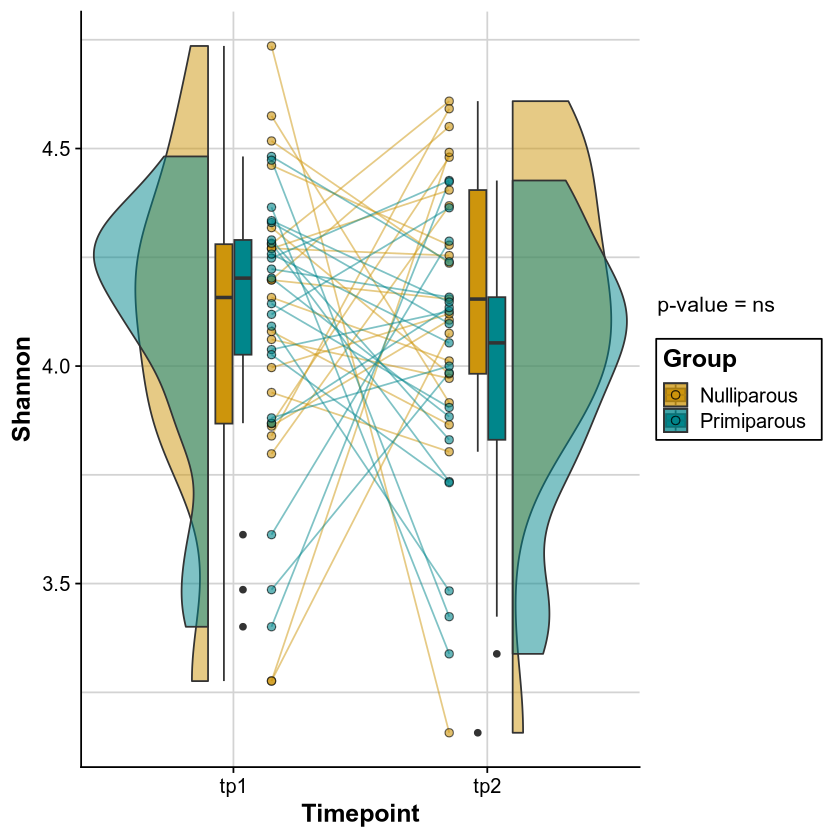

In [35]:
dye <- c("Nulliparous" = "darkgoldenrod3", "Primiparous" = "turquoise4")

df_shan_long |> 
    ggplot(aes(x = Timepoint, y = Shannon, fill = Group)) +
    geom_boxplot(width = 0.15) +
    #geom_rain()+
# Handles tp1 half
    geom_violinhalf(alpha = 0.5, flip = c(1,2), data = df_shan_long |>
                    filter(Timepoint == "tp1"), position = position_nudge(-0.1)
                   ) +
# Handles tp2 half
   geom_violinhalf(alpha = 0.5, flip = c(3,4), data = df_shan_long |>
                    filter(Timepoint == "tp2"), position = position_nudge(0.1)
                   ) +
# Ensures that only points of the same personal# and Group are connected 
    geom_line(
        data = df_shan_long |> 
        group_by(Personal_number, Group, Timepoint) |> 
        ungroup(),
        mapping = aes(
        x = ifelse(Timepoint == "tp1", 1.15, 1.85), # Ofset since the geom_jitter is nudged
        y = Shannon,
        group = interaction(Personal_number, Group),
        color = Group
        ),
      alpha = 0.5,
      linewidth = 0.5
            ) +
    geom_jitter(data = df_shan_long |>
                    filter(Timepoint == "tp1"), position = position_nudge(0.15), shape = 21, alpha = 0.6, size = 2) +
    geom_jitter(data = df_shan_long |>
                    filter(Timepoint == "tp2"), position = position_nudge(-0.15), shape = 21, alpha = 0.6, size = 2) +
    scale_fill_manual(values = dye) +
    scale_colour_manual(values = dye) +
       annotate("text", x = Inf, y = Inf, label="p-value = ns", hjust = -0.15, vjust = 20, size = 4.5) +

# Prevents ggplot from cutting of elements outside plot area
    coord_cartesian(clip = "off") +
    theme_half_open() +
theme(
        legend.box.background = element_rect(color = "Black", size = 0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")
    )

### Significance-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [36]:
# Select variables of interest
shan_wide_delta <- df_shan_long |> filter(Timepoint == "tp2") |> 
    select(Personal_number, Group, delta) |> 
    pivot_wider(
    names_from = Group,
    values_from = delta)
    
head(shan_wide_delta)

Personal_number,Nulliparous,Primiparous
<chr>,<dbl>,<dbl>
P159f9c8,-0.28087121,-1.0265635
P1a267fa,-0.18356955,-0.5478045
P1f862a6,-0.13625628,0.6746461
P3cac7b0,-0.08945654,0.1781994
P3db7da6,0.79906742,-0.2323886
P424fd61,0.24389727,0.4984070


In [37]:
shan_wide_delta <- shan_wide_delta |> rename(Nulliparous_delta = Nulliparous)
shan_wide_delta <- shan_wide_delta |> rename(Primiparous_delta = Primiparous)
head(shan_wide_delta)
dim(shan_wide_delta)

Personal_number,Nulliparous_delta,Primiparous_delta
<chr>,<dbl>,<dbl>
P159f9c8,-0.28087121,-1.0265635
P1a267fa,-0.18356955,-0.5478045
P1f862a6,-0.13625628,0.6746461
P3cac7b0,-0.08945654,0.1781994
P3db7da6,0.79906742,-0.2323886
P424fd61,0.24389727,0.4984070


[1] 21  3

In [38]:
shan_wide_delta$difference <- shan_wide_delta$Primiparous_delta - shan_wide_delta$Nulliparous_delta
shapiro.test(shan_wide_delta$difference)


	Shapiro-Wilk normality test

data:  shan_wide_delta$difference
W = 0.9199, p-value = 0.08637


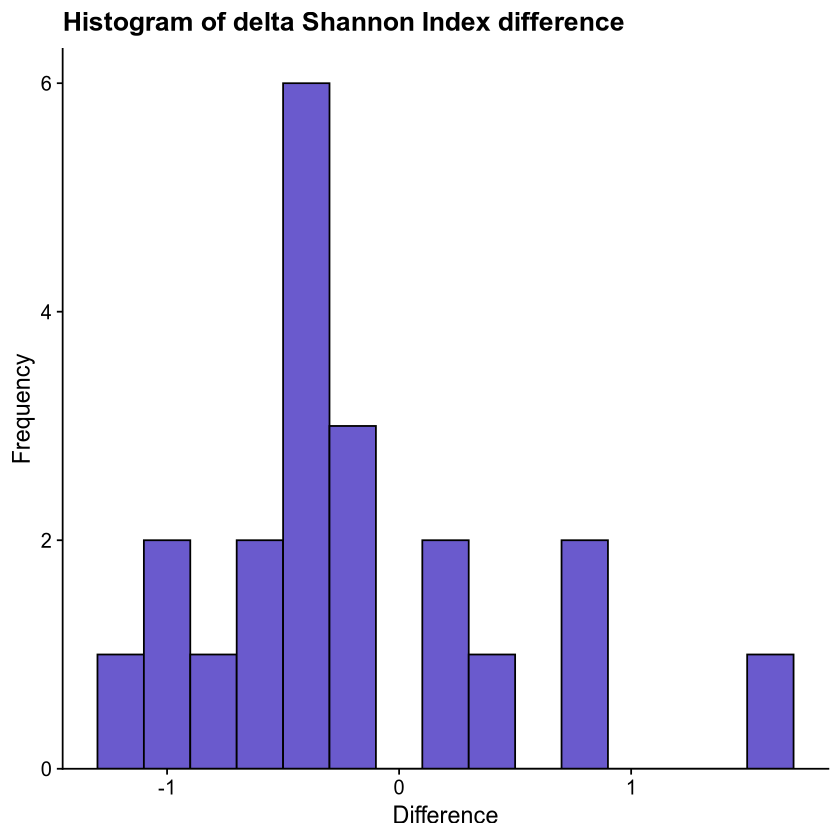

In [39]:
# Plot distribution
shan_wide_delta |> ggplot(aes(x = difference)) +
    geom_histogram( binwidth = 0.2, position = "identity", fill = "slateblue", col = "black") +
    labs(
    title = "Histogram of delta Shannon Index difference",
    x = "Difference",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open()

In [40]:
t.test(Pair(Nulliparous_delta, Primiparous_delta) ~ 1,data = shan_wide_delta)


	Paired t-test

data:  Pair(Nulliparous_delta, Primiparous_delta)
t = 1.1835, df = 20, p-value = 0.2505
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -0.1389988  0.5035688
sample estimates:
mean difference 
       0.182285 


## Richness------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### First pregnancy

In [41]:
tp1_richness_combined$Group <- as.factor(tp1_richness_combined$Group)
head(tp1_richness_combined)
tp2_richness_combined$Group <- as.factor(tp2_richness_combined$Group)
head(tp2_richness_combined)

,Sample_ID,Species_richness,Group,Personal_number
,<dbl>,<int>,<fct>,<chr>
1,100000115046,406,Nulliparous,P159f9c8
2,100000133514,416,Nulliparous,P1a267fa
3,100000141564,304,Nulliparous,P1ef420d
4,100000112861,336,Nulliparous,P1f862a6
5,100000116982,385,Nulliparous,P3c0f6ee
6,100000117590,380,Nulliparous,P3cac7b0


,Sample_ID,Species_richness,Group,Personal_number
,<dbl>,<int>,<fct>,<chr>
1,100000112243,299,Nulliparous,P159f9c8
2,100000133958,307,Nulliparous,P1a267fa
3,100000168325,311,Nulliparous,P1f862a6
4,100000129494,227,Nulliparous,P3cac7b0
5,100000126820,341,Nulliparous,P3db7da6
6,100000123362,274,Nulliparous,P424fd61


In [42]:
# Create a df for Fp tp1
richness_fp_tp1 <- tp1_richness_combined |> filter(Group == "Nulliparous")
head(richness_fp_tp1)
dim(richness_fp_tp1)

,Sample_ID,Species_richness,Group,Personal_number
,<dbl>,<int>,<fct>,<chr>
1,100000115046,406,Nulliparous,P159f9c8
2,100000133514,416,Nulliparous,P1a267fa
3,100000141564,304,Nulliparous,P1ef420d
4,100000112861,336,Nulliparous,P1f862a6
5,100000116982,385,Nulliparous,P3c0f6ee
6,100000117590,380,Nulliparous,P3cac7b0


[1] 25  4

In [43]:
# Sanity check
unique(richness_fp_tp1$Group)
table(richness_fp_tp1$Group)

[1] Nulliparous
Levels: Nulliparous Primiparous


Nulliparous Primiparous 
         25           0 

In [44]:
# Create df for Fp tp2
richness_fp_tp2 <- tp2_richness_combined |>
    filter(Group == "Nulliparous")
dim(richness_fp_tp2)
head(richness_fp_tp2)

[1] 21  4

,Sample_ID,Species_richness,Group,Personal_number
,<dbl>,<int>,<fct>,<chr>
1,100000112243,299,Nulliparous,P159f9c8
2,100000133958,307,Nulliparous,P1a267fa
3,100000168325,311,Nulliparous,P1f862a6
4,100000129494,227,Nulliparous,P3cac7b0
5,100000126820,341,Nulliparous,P3db7da6
6,100000123362,274,Nulliparous,P424fd61


In [45]:
# Sanity check
unique(richness_fp_tp2$Group)
table(richness_fp_tp2$Group)

[1] Nulliparous
Levels: Nulliparous Primiparous


Nulliparous Primiparous 
         21           0 

In [46]:
# Merge df by Personal num & add sufixes to colnmes
richness_merged_fp <- merge(richness_fp_tp1, richness_fp_tp2, by= "Personal_number", suffixes = c("_tp1", "_tp2"))
dim(richness_merged_fp)
head(richness_merged_fp)

[1] 21  7

,Personal_number,Sample_ID_tp1,Species_richness_tp1,Group_tp1,Sample_ID_tp2,Species_richness_tp2,Group_tp2
,<chr>,<dbl>,<int>,<fct>,<dbl>,<int>,<fct>
1,P159f9c8,100000115046,406,Nulliparous,100000112243,299,Nulliparous
2,P1a267fa,100000133514,416,Nulliparous,100000133958,307,Nulliparous
3,P1f862a6,100000112861,336,Nulliparous,100000168325,311,Nulliparous
4,P3cac7b0,100000117590,380,Nulliparous,100000129494,227,Nulliparous
5,P3db7da6,100000126486,161,Nulliparous,100000126820,341,Nulliparous
6,P424fd61,100000114162,210,Nulliparous,100000123362,274,Nulliparous


In [47]:
# Do calculation
richness_merged_fp$delta <- richness_merged_fp$Species_richness_tp2 - richness_merged_fp$Species_richness_tp1
head(richness_merged_fp)

,Personal_number,Sample_ID_tp1,Species_richness_tp1,Group_tp1,Sample_ID_tp2,Species_richness_tp2,Group_tp2,delta
,<chr>,<dbl>,<int>,<fct>,<dbl>,<int>,<fct>,<int>
1,P159f9c8,100000115046,406,Nulliparous,100000112243,299,Nulliparous,-107
2,P1a267fa,100000133514,416,Nulliparous,100000133958,307,Nulliparous,-109
3,P1f862a6,100000112861,336,Nulliparous,100000168325,311,Nulliparous,-25
4,P3cac7b0,100000117590,380,Nulliparous,100000129494,227,Nulliparous,-153
5,P3db7da6,100000126486,161,Nulliparous,100000126820,341,Nulliparous,180
6,P424fd61,100000114162,210,Nulliparous,100000123362,274,Nulliparous,64


### Second pregnancy

In [48]:
# Create a df for Sp tp1
richness_sp_tp1 <- tp1_richness_combined |> filter(Group == "Primiparous")
head(richness_sp_tp1)
dim(richness_sp_tp1)

,Sample_ID,Species_richness,Group,Personal_number
,<dbl>,<int>,<fct>,<chr>
1,100000138427,359,Primiparous,P159f9c8
2,100000416914,373,Primiparous,P1a267fa
3,100000416341,352,Primiparous,P1ef420d
4,100000417300,306,Primiparous,P1f862a6
5,100000415924,250,Primiparous,P3c0f6ee
6,100000417676,393,Primiparous,P3cac7b0


[1] 25  4

In [49]:
# Sanity check
unique(richness_sp_tp1$Group)
table(richness_sp_tp1$Group)

[1] Primiparous
Levels: Nulliparous Primiparous


Nulliparous Primiparous 
          0          25 

In [50]:
# Create a df for Sp tp2
richness_sp_tp2 <- tp2_richness_combined |> filter(Group == "Primiparous")
head(richness_sp_tp2)
dim(richness_sp_tp2)

,Sample_ID,Species_richness,Group,Personal_number
,<dbl>,<int>,<fct>,<chr>
1,100000418123,151,Primiparous,P159f9c8
2,100000421192,219,Primiparous,P1a267fa
3,100000427415,410,Primiparous,P1f862a6
4,100000426753,389,Primiparous,P3cac7b0
5,100000433799,237,Primiparous,P3db7da6
6,100000406809,304,Primiparous,P424fd61


[1] 21  4

In [51]:
# Sanity check
unique(richness_sp_tp2$Group)
table(richness_sp_tp2$Group)

[1] Primiparous
Levels: Nulliparous Primiparous


Nulliparous Primiparous 
          0          21 

### Plot------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [52]:
# Merge df by Personal num & add sufixes to colnmes
richness_merged_sp <- merge(richness_sp_tp1, richness_sp_tp2, by= "Personal_number", suffixes = c("_tp1", "_tp2"))
dim(richness_merged_sp)
head(richness_merged_sp)

[1] 21  7

,Personal_number,Sample_ID_tp1,Species_richness_tp1,Group_tp1,Sample_ID_tp2,Species_richness_tp2,Group_tp2
,<chr>,<dbl>,<int>,<fct>,<dbl>,<int>,<fct>
1,P159f9c8,100000138427,359,Primiparous,100000418123,151,Primiparous
2,P1a267fa,100000416914,373,Primiparous,100000421192,219,Primiparous
3,P1f862a6,100000417300,306,Primiparous,100000427415,410,Primiparous
4,P3cac7b0,100000417676,393,Primiparous,100000426753,389,Primiparous
5,P3db7da6,100000402412,349,Primiparous,100000433799,237,Primiparous
6,P424fd61,100000401705,158,Primiparous,100000406809,304,Primiparous


In [53]:
# Do calulations
richness_merged_sp$delta <- richness_merged_sp$Species_richness_tp2 - richness_merged_sp$Species_richness_tp1
head(richness_merged_sp)

,Personal_number,Sample_ID_tp1,Species_richness_tp1,Group_tp1,Sample_ID_tp2,Species_richness_tp2,Group_tp2,delta
,<chr>,<dbl>,<int>,<fct>,<dbl>,<int>,<fct>,<int>
1,P159f9c8,100000138427,359,Primiparous,100000418123,151,Primiparous,-208
2,P1a267fa,100000416914,373,Primiparous,100000421192,219,Primiparous,-154
3,P1f862a6,100000417300,306,Primiparous,100000427415,410,Primiparous,104
4,P3cac7b0,100000417676,393,Primiparous,100000426753,389,Primiparous,-4
5,P3db7da6,100000402412,349,Primiparous,100000433799,237,Primiparous,-112
6,P424fd61,100000401705,158,Primiparous,100000406809,304,Primiparous,146


In [54]:
richness_combined_df <- rbind(richness_merged_fp, richness_merged_sp)
head(richness_combined_df)

,Personal_number,Sample_ID_tp1,Species_richness_tp1,Group_tp1,Sample_ID_tp2,Species_richness_tp2,Group_tp2,delta
,<chr>,<dbl>,<int>,<fct>,<dbl>,<int>,<fct>,<int>
1,P159f9c8,100000115046,406,Nulliparous,100000112243,299,Nulliparous,-107
2,P1a267fa,100000133514,416,Nulliparous,100000133958,307,Nulliparous,-109
3,P1f862a6,100000112861,336,Nulliparous,100000168325,311,Nulliparous,-25
4,P3cac7b0,100000117590,380,Nulliparous,100000129494,227,Nulliparous,-153
5,P3db7da6,100000126486,161,Nulliparous,100000126820,341,Nulliparous,180
6,P424fd61,100000114162,210,Nulliparous,100000123362,274,Nulliparous,64


In [55]:
# Reshape df into long format for easier plotting

df_richness_long <- richness_combined_df |>
    select(Personal_number, Species_richness_tp1, Species_richness_tp2, Group_tp2, delta) |>
pivot_longer(cols = c(Species_richness_tp1, Species_richness_tp2),
            names_to = "Timepoint", 
            values_to = "Richness") |>
    mutate(Timepoint = as.factor(ifelse(Timepoint == "Species_richness_tp1", "tp1", "tp2")))

names(df_richness_long)[2] <- "Group"

dim(df_richness_long)
head(df_richness_long)

[1] 84  5

Personal_number,Group,delta,Timepoint,Richness
<chr>,<fct>,<int>,<fct>,<int>
P159f9c8,Nulliparous,-107,tp1,406
P159f9c8,Nulliparous,-107,tp2,299
P1a267fa,Nulliparous,-109,tp1,416
P1a267fa,Nulliparous,-109,tp2,307
P1f862a6,Nulliparous,-25,tp1,336
P1f862a6,Nulliparous,-25,tp2,311


In [56]:
# Check that pn are correct
df_richness_long |> filter(Personal_number == "P159f9c8")

Personal_number,Group,delta,Timepoint,Richness
<chr>,<fct>,<int>,<fct>,<int>
P159f9c8,Nulliparous,-107,tp1,406
P159f9c8,Nulliparous,-107,tp2,299
P159f9c8,Primiparous,-208,tp1,359
P159f9c8,Primiparous,-208,tp2,151


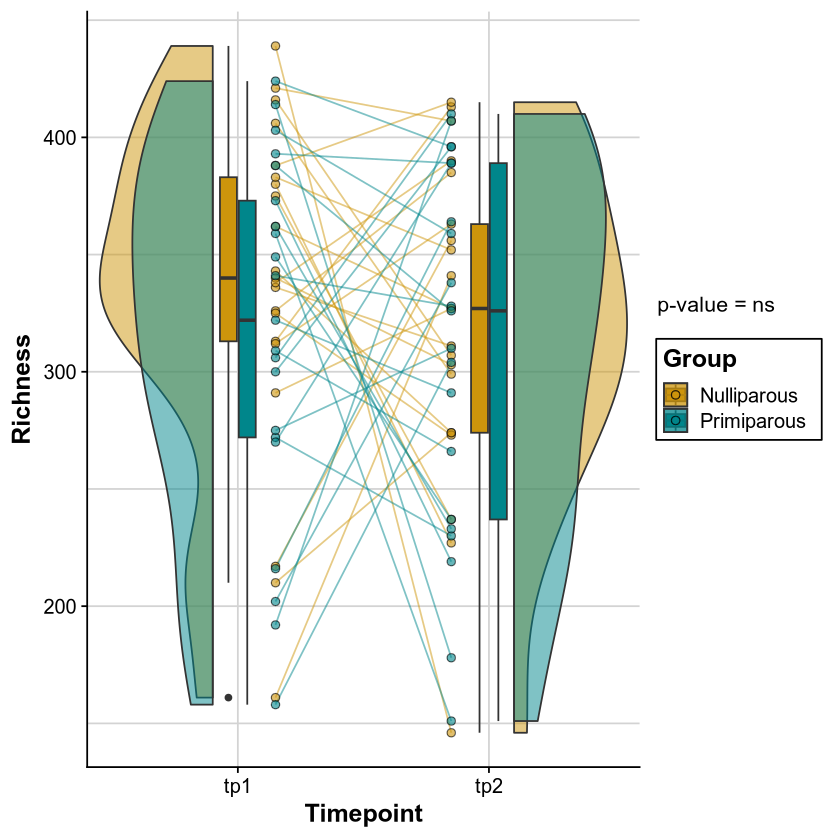

In [57]:
df_richness_long |> 
    ggplot(aes(x = Timepoint, y = Richness, fill = Group)) +
    geom_boxplot(width = 0.15) +
    #geom_rain()+
# Handles tp1 half
    geom_violinhalf(alpha = 0.5, flip = c(1,2), data = df_richness_long |>
                    filter(Timepoint == "tp1"), position = position_nudge(-0.1)
                   ) +
# Handles tp2 half
   geom_violinhalf(alpha = 0.5, flip = c(3,4), data = df_richness_long |>
                    filter(Timepoint == "tp2"), position = position_nudge(0.1)
                   ) +
# Ensures that only points of the same personal# and Group are connected 
    geom_line(
        data = df_richness_long |> 
        group_by(Personal_number, Group, Timepoint) |> 
        ungroup(),
        mapping = aes(
        x = ifelse(Timepoint == "tp1", 1.15, 1.85), # Ofset since the geom_jitter is nudged
        y = Richness,
        group = interaction(Personal_number, Group),
        color = Group
        ),
      alpha = 0.5,
      linewidth = 0.5
            ) +
    geom_jitter(data = df_richness_long |>
                    filter(Timepoint == "tp1"), position = position_nudge(0.15), shape = 21, alpha = 0.6, size = 2) +
    geom_jitter(data = df_richness_long |>
                    filter(Timepoint == "tp2"), position = position_nudge(-0.15), shape = 21, alpha = 0.6, size = 2) +
    scale_fill_manual(values = dye) +
    scale_colour_manual(values = dye) +
        annotate("text", x = Inf, y = Inf, label="p-value = ns", hjust = -0.15, vjust = 20, size = 4.5) +
# Prevents ggplot from cutting of elements outside plot area
    coord_cartesian(clip = "off") +
    theme_half_open() +
theme(
        legend.box.background = element_rect(color = "Black", size = 0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")
    )

### Significance------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [58]:
# Create a wide table
# Select variables of interest
rich_wide_delta <- df_richness_long |> filter(Timepoint == "tp2") |> 
    select(Personal_number, Group, delta) |> 
    pivot_wider(
    names_from = Group,
    values_from = delta)
    
head(rich_wide_delta)

Personal_number,Nulliparous,Primiparous
<chr>,<int>,<int>
P159f9c8,-107,-208
P1a267fa,-109,-154
P1f862a6,-25,104
P3cac7b0,-153,-4
P3db7da6,180,-112
P424fd61,64,146


In [59]:
rich_wide_delta <- rich_wide_delta |> rename(Nulliparous_delta = Nulliparous)
rich_wide_delta <- rich_wide_delta |> rename(Primiparous_delta = Primiparous)
head(rich_wide_delta)
dim(rich_wide_delta)

Personal_number,Nulliparous_delta,Primiparous_delta
<chr>,<int>,<int>
P159f9c8,-107,-208
P1a267fa,-109,-154
P1f862a6,-25,104
P3cac7b0,-153,-4
P3db7da6,180,-112
P424fd61,64,146


[1] 21  3

In [60]:
rich_wide_delta$difference <- rich_wide_delta$Primiparous_delta - rich_wide_delta$Nulliparous_delta
shapiro.test(rich_wide_delta$difference)


	Shapiro-Wilk normality test

data:  rich_wide_delta$difference
W = 0.96334, p-value = 0.5859


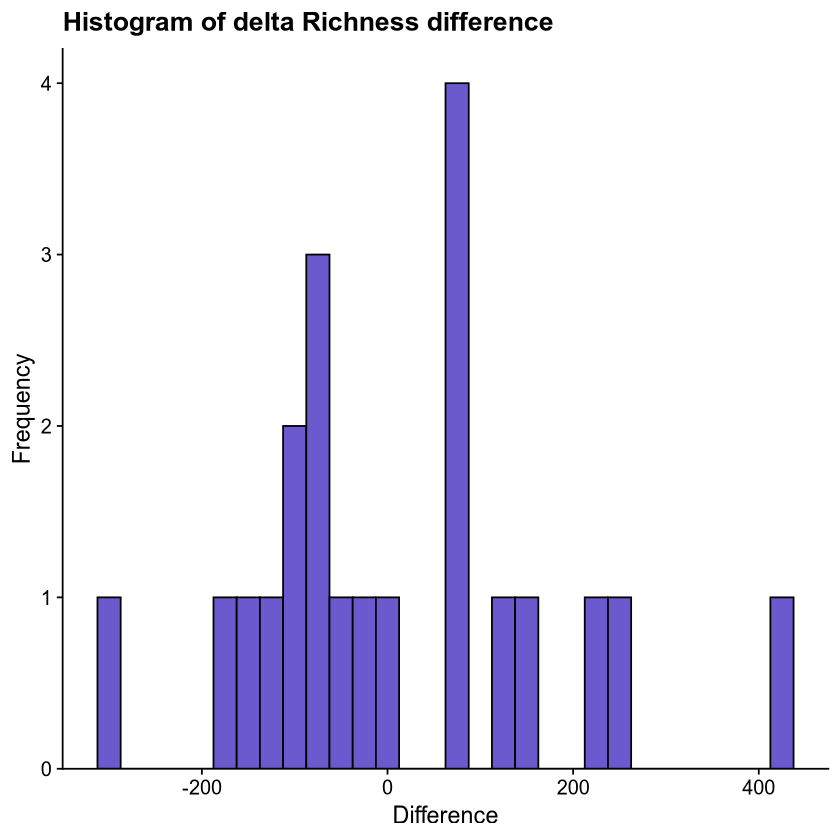

In [61]:
# Plot distribution
rich_wide_delta |> ggplot(aes(x = difference)) +
    geom_histogram( binwidth = 25, position = "identity", fill = "slateblue", col = "black") +
    labs(
    title = "Histogram of delta Richness difference",
    x = "Difference",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open()

In [62]:
t.test(Pair(Nulliparous_delta, Primiparous_delta) ~ 1,data = rich_wide_delta)


	Paired t-test

data:  Pair(Nulliparous_delta, Primiparous_delta)
t = -0.32748, df = 20, p-value = 0.7467
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -87.03304  63.41399
sample estimates:
mean difference 
      -11.80952 


## Species Evenness---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### First pregnancy 

In [63]:
tp1_evenness_combined$Group <- as.factor(tp1_evenness_combined$Group)
head(tp1_evenness_combined)
tp2_evenness_combined$Group <- as.factor(tp2_evenness_combined$Group)
head(tp2_evenness_combined)

,Sample_ID,Evenness,Group,Personal_number
,<dbl>,<dbl>,<fct>,<chr>
1,100000115046,0.7521035,Nulliparous,P159f9c8
2,100000133514,0.7397825,Nulliparous,P1a267fa
3,100000141564,0.7009359,Nulliparous,P1ef420d
4,100000112861,0.6771863,Nulliparous,P1f862a6
5,100000116982,0.7290663,Nulliparous,P3c0f6ee
6,100000117590,0.6836731,Nulliparous,P3cac7b0


,Sample_ID,Evenness,Group,Personal_number
,<dbl>,<dbl>,<fct>,<chr>
1,100000112243,0.7431927,Nulliparous,P159f9c8
2,100000133958,0.7469774,Nulliparous,P1a267fa
3,100000168325,0.6625695,Nulliparous,P1f862a6
4,100000129494,0.7321135,Nulliparous,P3cac7b0
5,100000126820,0.6987976,Nulliparous,P3db7da6
6,100000123362,0.7314601,Nulliparous,P424fd61


In [64]:
# Create a df with just fp tp1
# Create a df for fp tp1
evenness_fp_tp1 <- tp1_evenness_combined |> filter(Group == "Nulliparous")
head(evenness_fp_tp1)
dim(evenness_fp_tp1)

,Sample_ID,Evenness,Group,Personal_number
,<dbl>,<dbl>,<fct>,<chr>
1,100000115046,0.7521035,Nulliparous,P159f9c8
2,100000133514,0.7397825,Nulliparous,P1a267fa
3,100000141564,0.7009359,Nulliparous,P1ef420d
4,100000112861,0.6771863,Nulliparous,P1f862a6
5,100000116982,0.7290663,Nulliparous,P3c0f6ee
6,100000117590,0.6836731,Nulliparous,P3cac7b0


[1] 25  4

In [65]:
# Sanity check
unique(evenness_fp_tp1$Group)
table(evenness_fp_tp1$Group)

[1] Nulliparous
Levels: Nulliparous Primiparous


Nulliparous Primiparous 
         25           0 

In [66]:
# Create a df with just fp tp2
# Create a df for fp tp1
evenness_fp_tp2 <- tp2_evenness_combined |> filter(Group == "Nulliparous")
head(evenness_fp_tp2)
dim(evenness_fp_tp2)

,Sample_ID,Evenness,Group,Personal_number
,<dbl>,<dbl>,<fct>,<chr>
1,100000112243,0.7431927,Nulliparous,P159f9c8
2,100000133958,0.7469774,Nulliparous,P1a267fa
3,100000168325,0.6625695,Nulliparous,P1f862a6
4,100000129494,0.7321135,Nulliparous,P3cac7b0
5,100000126820,0.6987976,Nulliparous,P3db7da6
6,100000123362,0.7314601,Nulliparous,P424fd61


[1] 21  4

In [67]:
unique(evenness_fp_tp2$Group)
table(evenness_fp_tp2$Group)

[1] Nulliparous
Levels: Nulliparous Primiparous


Nulliparous Primiparous 
         21           0 

In [68]:
# Merge df by Personal num & add sufixes to colnmes
evenness_merged_fp <- merge(evenness_fp_tp2, evenness_fp_tp1, by= "Personal_number", suffixes = c("_tp1", "_tp2"))
dim(evenness_merged_fp)
head(evenness_merged_fp)

[1] 21  7

,Personal_number,Sample_ID_tp1,Evenness_tp1,Group_tp1,Sample_ID_tp2,Evenness_tp2,Group_tp2
,<chr>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<fct>
1,P159f9c8,100000112243,0.7431927,Nulliparous,100000115046,0.7521035,Nulliparous
2,P1a267fa,100000133958,0.7469774,Nulliparous,100000133514,0.7397825,Nulliparous
3,P1f862a6,100000168325,0.6625695,Nulliparous,100000112861,0.6771863,Nulliparous
4,P3cac7b0,100000129494,0.7321135,Nulliparous,100000117590,0.6836731,Nulliparous
5,P3db7da6,100000126820,0.6987976,Nulliparous,100000126486,0.6447505,Nulliparous
6,P424fd61,100000123362,0.7314601,Nulliparous,100000114162,0.7222376,Nulliparous


In [69]:
# Do calculation
evenness_merged_fp$delta <- evenness_merged_fp$Evenness_tp2 - evenness_merged_fp$Evenness_tp1
head(evenness_merged_fp)

,Personal_number,Sample_ID_tp1,Evenness_tp1,Group_tp1,Sample_ID_tp2,Evenness_tp2,Group_tp2,delta
,<chr>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<fct>,<dbl>
1,P159f9c8,100000112243,0.7431927,Nulliparous,100000115046,0.7521035,Nulliparous,0.008910806
2,P1a267fa,100000133958,0.7469774,Nulliparous,100000133514,0.7397825,Nulliparous,-0.007194907
3,P1f862a6,100000168325,0.6625695,Nulliparous,100000112861,0.6771863,Nulliparous,0.014616804
4,P3cac7b0,100000129494,0.7321135,Nulliparous,100000117590,0.6836731,Nulliparous,-0.048440332
5,P3db7da6,100000126820,0.6987976,Nulliparous,100000126486,0.6447505,Nulliparous,-0.054047084
6,P424fd61,100000123362,0.7314601,Nulliparous,100000114162,0.7222376,Nulliparous,-0.009222525


### Second Pregnancy

In [70]:
# Create a df with sp tp1
evenness_sp_tp1 <- tp1_evenness_combined |> filter(Group == "Primiparous")
head(evenness_sp_tp1)
dim(evenness_sp_tp1)

,Sample_ID,Evenness,Group,Personal_number
,<dbl>,<dbl>,<fct>,<chr>
1,100000138427,0.7419310,Primiparous,P159f9c8
2,100000416914,0.7231626,Primiparous,P1a267fa
3,100000416341,0.7203988,Primiparous,P1ef420d
4,100000417300,0.6311500,Primiparous,P1f862a6
5,100000415924,0.7351540,Primiparous,P3c0f6ee
6,100000417676,0.7111540,Primiparous,P3cac7b0


[1] 25  4

In [71]:
unique(evenness_sp_tp1$Group)
table(evenness_sp_tp1$Group)

[1] Primiparous
Levels: Nulliparous Primiparous


Nulliparous Primiparous 
          0          25 

In [72]:
# Create a df with sp tp1
evenness_sp_tp2 <- tp2_evenness_combined |> filter(Group == "Primiparous")
head(evenness_sp_tp2)
dim(evenness_sp_tp2)

,Sample_ID,Evenness,Group,Personal_number
,<dbl>,<dbl>,<fct>,<chr>
1,100000418123,0.6653916,Primiparous,P159f9c8
2,100000421192,0.6929690,Primiparous,P1a267fa
3,100000427415,0.7125956,Primiparous,P1f862a6
4,100000426753,0.7422553,Primiparous,P3cac7b0
5,100000433799,0.7493484,Primiparous,P3db7da6
6,100000406809,0.6969338,Primiparous,P424fd61


[1] 21  4

In [73]:
unique(evenness_sp_tp2$Group)
table(evenness_sp_tp2$Group)

[1] Primiparous
Levels: Nulliparous Primiparous


Nulliparous Primiparous 
          0          21 

In [74]:
# Merge df by Personal num & add sufixes to colnmes
evenness_merged_sp <- merge(evenness_sp_tp2, evenness_sp_tp1, by= "Personal_number", suffixes = c("_tp1", "_tp2"))
dim(evenness_merged_sp)
head(evenness_merged_sp)

[1] 21  7

,Personal_number,Sample_ID_tp1,Evenness_tp1,Group_tp1,Sample_ID_tp2,Evenness_tp2,Group_tp2
,<chr>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<fct>
1,P159f9c8,100000418123,0.6653916,Primiparous,100000138427,0.7419310,Primiparous
2,P1a267fa,100000421192,0.6929690,Primiparous,100000416914,0.7231626,Primiparous
3,P1f862a6,100000427415,0.7125956,Primiparous,100000417300,0.6311500,Primiparous
4,P3cac7b0,100000426753,0.7422553,Primiparous,100000417676,0.7111540,Primiparous
5,P3db7da6,100000433799,0.7493484,Primiparous,100000402412,0.7395077,Primiparous
6,P424fd61,100000406809,0.6969338,Primiparous,100000401705,0.6885763,Primiparous


In [75]:
# Do calulations for Sp
evenness_merged_sp$delta <- evenness_merged_sp$Evenness_tp2 - evenness_merged_sp$Evenness_tp1
head(evenness_merged_sp)

,Personal_number,Sample_ID_tp1,Evenness_tp1,Group_tp1,Sample_ID_tp2,Evenness_tp2,Group_tp2,delta
,<chr>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<fct>,<dbl>
1,P159f9c8,100000418123,0.6653916,Primiparous,100000138427,0.7419310,Primiparous,0.076539406
2,P1a267fa,100000421192,0.6929690,Primiparous,100000416914,0.7231626,Primiparous,0.030193622
3,P1f862a6,100000427415,0.7125956,Primiparous,100000417300,0.6311500,Primiparous,-0.081445556
4,P3cac7b0,100000426753,0.7422553,Primiparous,100000417676,0.7111540,Primiparous,-0.031101237
5,P3db7da6,100000433799,0.7493484,Primiparous,100000402412,0.7395077,Primiparous,-0.009840713
6,P424fd61,100000406809,0.6969338,Primiparous,100000401705,0.6885763,Primiparous,-0.008357531


### Plot------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [76]:
evenness_combined_df <- rbind(evenness_merged_fp, evenness_merged_sp)
head(evenness_combined_df)

,Personal_number,Sample_ID_tp1,Evenness_tp1,Group_tp1,Sample_ID_tp2,Evenness_tp2,Group_tp2,delta
,<chr>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<fct>,<dbl>
1,P159f9c8,100000112243,0.7431927,Nulliparous,100000115046,0.7521035,Nulliparous,0.008910806
2,P1a267fa,100000133958,0.7469774,Nulliparous,100000133514,0.7397825,Nulliparous,-0.007194907
3,P1f862a6,100000168325,0.6625695,Nulliparous,100000112861,0.6771863,Nulliparous,0.014616804
4,P3cac7b0,100000129494,0.7321135,Nulliparous,100000117590,0.6836731,Nulliparous,-0.048440332
5,P3db7da6,100000126820,0.6987976,Nulliparous,100000126486,0.6447505,Nulliparous,-0.054047084
6,P424fd61,100000123362,0.7314601,Nulliparous,100000114162,0.7222376,Nulliparous,-0.009222525


In [77]:
# Reshape df into long format for easier plotting

df_evenness_long <- evenness_combined_df |>
    select(Personal_number, Evenness_tp1, Evenness_tp2, Group_tp2, delta) |>
pivot_longer(cols = c(Evenness_tp1, Evenness_tp2),
            names_to = "Timepoint", 
            values_to = "Evenness") |>
    mutate(Timepoint = as.factor(ifelse(Timepoint == "Evenness_tp1", "tp1", "tp2")))

names(df_evenness_long)[2] <- "Group"

dim(df_evenness_long)
head(df_evenness_long)

[1] 84  5

Personal_number,Group,delta,Timepoint,Evenness
<chr>,<fct>,<dbl>,<fct>,<dbl>
P159f9c8,Nulliparous,0.008910806,tp1,0.7431927
P159f9c8,Nulliparous,0.008910806,tp2,0.7521035
P1a267fa,Nulliparous,-0.007194907,tp1,0.7469774
P1a267fa,Nulliparous,-0.007194907,tp2,0.7397825
P1f862a6,Nulliparous,0.014616804,tp1,0.6625695
P1f862a6,Nulliparous,0.014616804,tp2,0.6771863


In [78]:
# Check that pn are correct
df_evenness_long |> filter(Personal_number == "P1a267fa")

Personal_number,Group,delta,Timepoint,Evenness
<chr>,<fct>,<dbl>,<fct>,<dbl>
P1a267fa,Nulliparous,-0.007194907,tp1,0.7469774
P1a267fa,Nulliparous,-0.007194907,tp2,0.7397825
P1a267fa,Primiparous,0.030193622,tp1,0.6929690
P1a267fa,Primiparous,0.030193622,tp2,0.7231626


ERROR: [1m[33mError[39m:[22m
[1m[22m[33m![39m Cannot add [34m<ggproto>[39m objects together.
[36mℹ[39m Did you forget to add this object to a [34m<ggplot>[39m object?


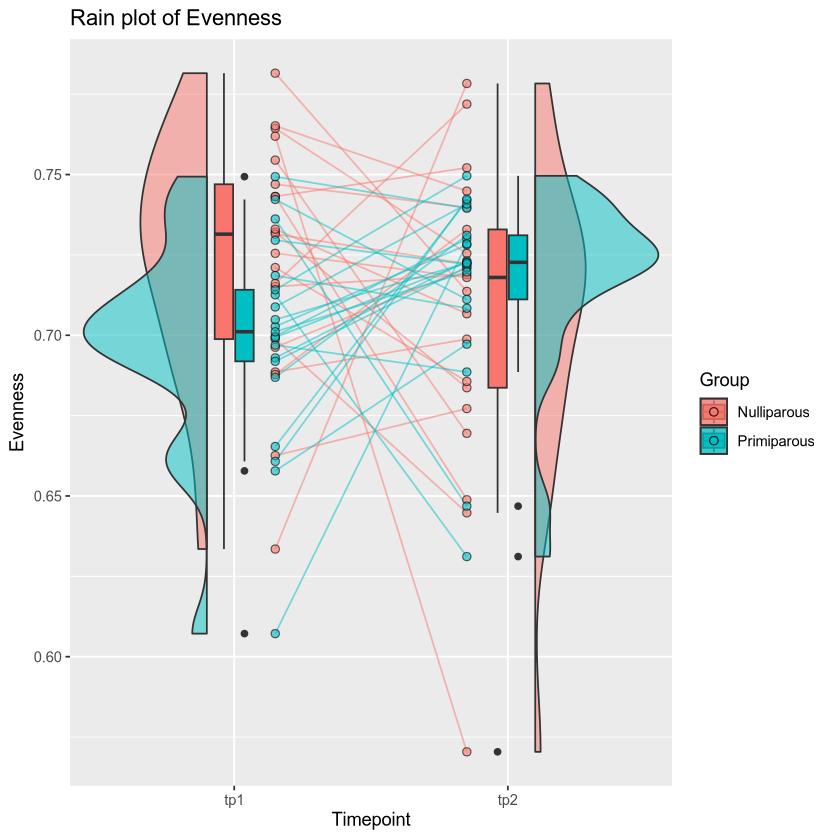

In [81]:
df_evenness_long |> 
    ggplot(aes(x = Timepoint, y = Evenness, fill = Group)) +
    geom_boxplot(width = 0.15) +
    #geom_rain()+
# Handles tp1 half
    geom_violinhalf(alpha = 0.5, flip = c(1,2), data = df_evenness_long |>
                    filter(Timepoint == "tp1"), position = position_nudge(-0.1)
                   ) +
# Handles tp2 half
   geom_violinhalf(alpha = 0.5, flip = c(3,4), data = df_evenness_long |>
                    filter(Timepoint == "tp2"), position = position_nudge(0.1)
                   ) +
# Ensures that only points of the same personal# and Group are connected 
    geom_line(
        data = df_evenness_long |> 
        group_by(Personal_number, Group, Timepoint) |> 
        ungroup(),
        mapping = aes(
        x = ifelse(Timepoint == "tp1", 1.15, 1.85), # Ofset since the geom_jitter is nudged
        y = Evenness,
        group = interaction(Personal_number, Group),
        color = Group
        ),
      alpha = 0.5,
      linewidth = 0.5
            ) +
    geom_jitter(data = df_evenness_long |>
                    filter(Timepoint == "tp1"), position = position_nudge(0.15), shape = 21, alpha = 0.6, size = 2) +
    geom_jitter(data = df_evenness_long |>
                    filter(Timepoint == "tp2"), position = position_nudge(-0.15), shape = 21, alpha = 0.6, size = 2) +
    labs(
        title = "Rain plot of Evenness"
    )
    scale_fill_manual(values = dye) +
    scale_colour_manual(values = dye)+
    theme_half_open() +
    annotate("text", x = Inf, y = Inf, label="p-value = 0.021", hjust = -0.15, vjust = 20, size = 4.5) +

# Prevents ggplot from cutting of elements outside plot area
    coord_cartesian(clip = "off") +
    theme(
        legend.box.background = element_rect(color = "Black", size = 0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")
    )

In [ ]:
df_richness_long |> 
    ggplot(aes(x = Timepoint, y = Richness, fill = Group)) +
    geom_boxplot(width = 0.15) +
    #geom_rain()+
# Handles tp1 half
    geom_violinhalf(alpha = 0.5, flip = c(1,2), data = df_richness_long |>
                    filter(Timepoint == "tp1"), position = position_nudge(-0.1)
                   ) +
# Handles tp2 half
   geom_violinhalf(alpha = 0.5, flip = c(3,4), data = df_richness_long |>
                    filter(Timepoint == "tp2"), position = position_nudge(0.1)
                   ) +
# Ensures that only points of the same personal# and Group are connected 
    geom_line(
        data = df_richness_long |> 
        group_by(Personal_number, Group, Timepoint) |> 
        ungroup(),
        mapping = aes(
        x = ifelse(Timepoint == "tp1", 1.15, 1.85), # Ofset since the geom_jitter is nudged
        y = Richness,
        group = interaction(Personal_number, Group),
        color = Group
        ),
      alpha = 0.5,
      linewidth = 0.5
            ) +
    geom_jitter(data = df_richness_long |>
                    filter(Timepoint == "tp1"), position = position_nudge(0.15), shape = 21, alpha = 0.6, size = 2) +
    geom_jitter(data = df_richness_long |>
                    filter(Timepoint == "tp2"), position = position_nudge(-0.15), shape = 21, alpha = 0.6, size = 2) +
    scale_fill_manual(values = dye) +
    scale_colour_manual(values = dye) +
        annotate("text", x = Inf, y = Inf, label="p-value = ns", hjust = -0.15, vjust = 20, size = 4.5) +
# Prevents ggplot from cutting of elements outside plot area
    coord_cartesian(clip = "off") +
    theme_half_open() +
theme(
        legend.box.background = element_rect(color = "Black", size = 0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")
    )

### Significance----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
# Create a wide table
# Select variables of interest
even_wide_delta <- df_evenness_long |> filter(Timepoint == "tp2") |> 
    select(Personal_number, Group, delta) |> 
    pivot_wider(
    names_from = Group,
    values_from = delta)
    
head(even_wide_delta)

In [ ]:
even_wide_delta <- even_wide_delta |> rename(Nulliparous_delta = Nulliparous)
even_wide_delta <- even_wide_delta |> rename(Primiparous_delta = Primiparous)
head(even_wide_delta)
dim(even_wide_delta)

In [ ]:
even_wide_delta$difference <- even_wide_delta$Primiparous_delta - even_wide_delta$Nulliparous_delta
shapiro.test(even_wide_delta$difference)

In [ ]:
# Plot distribution
even_wide_delta |> ggplot(aes(x = difference)) +
    geom_histogram( binwidth = 0.025, position = "identity", fill = "slateblue", col = "black") +
    labs(
    title = "Histogram of delta Evenness difference",
    x = "Difference",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open()

## Simpson------------------------------------------------------------------------------------------------------------------------------------------------

### First pregnancy

In [ ]:
tp1_simpson_combined$Group <- as.factor(tp1_simpson_combined$Group)
head(tp1_simpson_combined)
tp2_simpson_combined$Group <- as.factor(tp2_simpson_combined$Group)
head(tp2_simpson_combined)

In [ ]:
# Create a df with just fp tp1
# Create a df for fp tp1
simpson_fp_tp1 <- tp1_simpson_combined |> filter(Group == "Nulliparous")
head(simpson_fp_tp1)
dim(simpson_fp_tp1)

In [ ]:
# Create a df with just fp tp2
# Create a df for fp tp2
simpson_fp_tp2 <- tp2_simpson_combined |> filter(Group == "Nulliparous")
head(simpson_fp_tp2)
dim(simpson_fp_tp2)

In [ ]:
# Sanity check
unique(simpson_fp_tp1$Group)
table(simpson_fp_tp1$Group)

In [ ]:
# Sanity check
unique(simpson_fp_tp2$Group)
table(simpson_fp_tp2$Group)

In [ ]:
# Merge df by Personal num & add sufixes to colnmes
simpson_merged_fp <- merge(simpson_fp_tp2, simpson_fp_tp1, by= "Personal_number", suffixes = c("_tp1", "_tp2"))
dim(simpson_merged_fp)
head(simpson_merged_fp)

In [ ]:
# Do calculation and add as column
simpson_merged_fp$delta <- simpson_merged_fp$Simpson_tp2 - simpson_merged_fp$Simpson_tp1
head(simpson_merged_fp)

### Second Pregnancy

# $\Delta \Delta \alpha$=====================================================================================================================================

In [ ]:
t.test(Pair(Nulliparous_delta, Primiparous_delta) ~ 1,data = even_wide_delta)